### Data Loading and Initial Understanding

Importing Important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 Loading Dataset

In [2]:
transaction = pd.read_csv('../data/train_transaction.csv')
identity = pd.read_csv('../data/train_identity.csv')


Merge datasets

In [3]:
data = transaction.merge(identity, on='TransactionID', how='left')

Basic Overview

In [4]:
print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
display(data.head())

Dataset shape: (590540, 434)

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
print("\nColumn names:")
print(data.columns)


Column names:
Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)


In [6]:
print("\nDataset info:")
data.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


Target variable Exploration


Fraud vs Non-Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


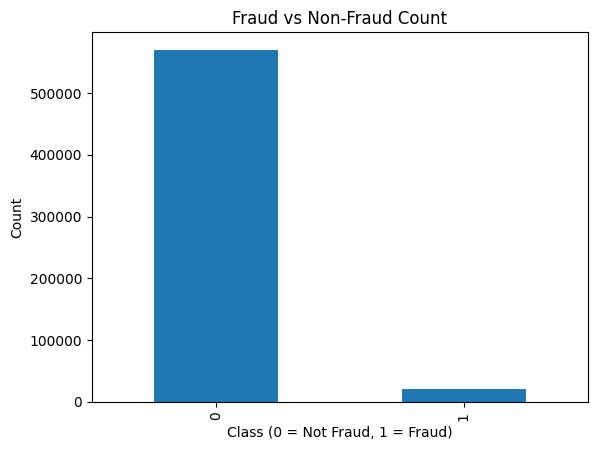

In [7]:
print("\nFraud vs Non-Fraud distribution:")
print(data['isFraud'].value_counts())


print("\nFraud percentage:")
print(data['isFraud'].value_counts(normalize=True) * 100)


data['isFraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Count")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

Missing Values Analysis

In [8]:
# Count missing values
missing_count = data.isnull().sum()
print("Missing Count:\n", missing_count)
print("-------------------------------")
# Percentage missing
missing_percent = (missing_count / len(data)) * 100
print ("Missing Percentage\n",missing_percent)

Missing Count:
 TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
id_36             449555
id_37             449555
id_38             449555
DeviceType        449730
DeviceInfo        471874
Length: 434, dtype: int64
-------------------------------
Missing Percentage
 TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
                    ...    
id_36             76.126088
id_37             76.126088
id_38             76.126088
DeviceType        76.155722
DeviceInfo        79.905510
Length: 434, dtype: float64


In [9]:
# Combine into a dataframe
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

# Sort by highest missing %
missing_df = missing_df.sort_values(by='Missing %', ascending=False)

missing_df.head(5)


,Missing Count,Missing %
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393


Multiple 'id' and 'D' columns have over 85-90% missing data. We should consider dropping these to reduce noise or creating binary indicators for 'is_missing'

### 4) TransactionAmt Analysis (Fraud vs Non-Fraud)


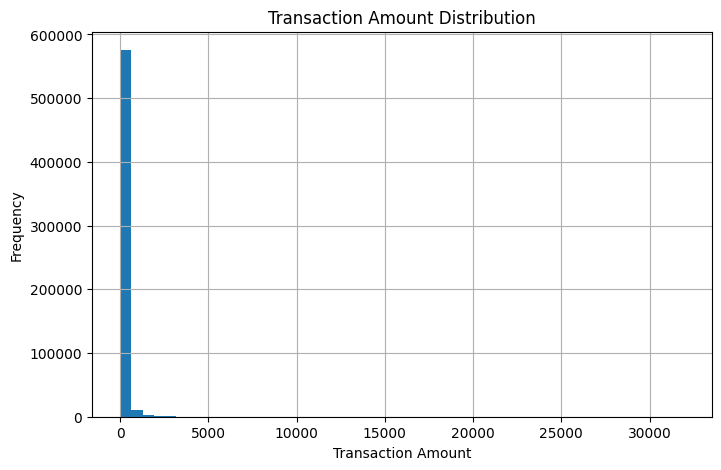

<Figure size 800x500 with 0 Axes>

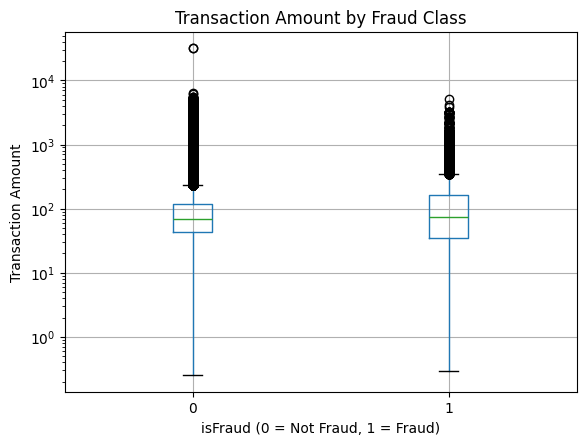

In [10]:
# TransactionAmt distribution
plt.figure(figsize=(8,5))
data['TransactionAmt'].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

# Compare TransactionAmt by Fraud vs Non-Fraud
plt.figure(figsize=(8,5))
data.boxplot(column='TransactionAmt', by='isFraud')
plt.title("Transaction Amount by Fraud Class")
plt.suptitle("")
plt.xlabel("isFraud (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.yscale("log")  # log scale because of large outliers
plt.show()

### 5) Categorical Feature Analysis (Fraud Rates)

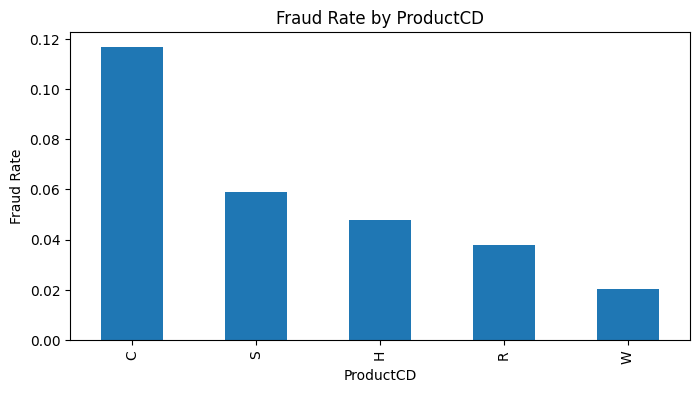

In [11]:
# Fraud rate by ProductCD
fraud_by_product = data.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
fraud_by_product.plot(kind='bar')
plt.title("Fraud Rate by ProductCD")
plt.ylabel("Fraud Rate")
plt.show()

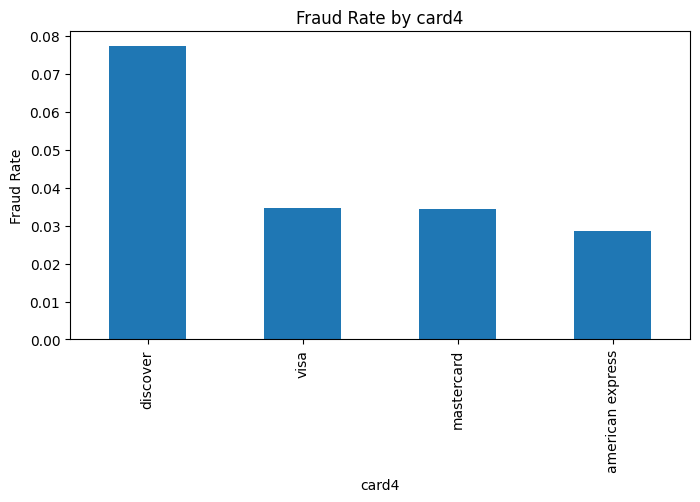

In [12]:
fraud_by_card4 = data.groupby('card4')['isFraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
fraud_by_card4.plot(kind='bar')
plt.title("Fraud Rate by card4")
plt.ylabel("Fraud Rate")
plt.show()

### 6) Correlation with Target (Numeric Features Only)

In [13]:
numeric_cols = data.select_dtypes(include=['int64','float64']).columns
corr = data[numeric_cols].corr()['isFraud'].sort_values(ascending=False)

print("Top positively correlated features with fraud:")
print(corr.head(15))

print("\nTop negatively correlated features with fraud:")
print(corr.tail(15))

Top positively correlated features with fraud:
isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
Name: isFraud, dtype: float64

Top negatively correlated features with fraud:
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
Name: isFraud, dtype: float64


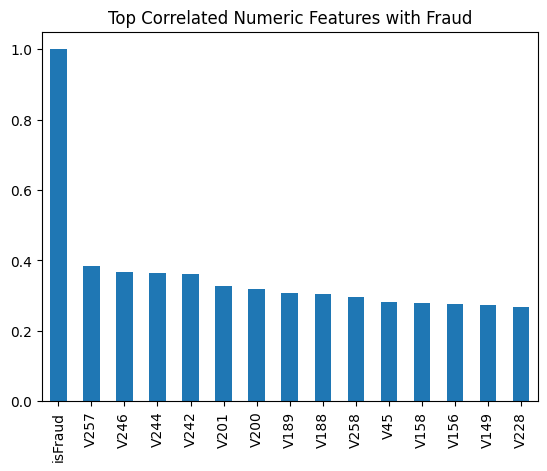

In [14]:

corr.head(15).plot(kind='bar')
plt.title("Top Correlated Numeric Features with Fraud")
plt.show()

Missingness vs Fraud Relationship

In [15]:
#checking whether missing DeviceType is linked to fraud
data['DeviceType_missing'] = data['DeviceType'].isnull().astype(int)

missing_fraud_rate = data.groupby('DeviceType_missing')['isFraud'].mean()
print(missing_fraud_rate)

DeviceType_missing
0    0.079618
1    0.021017
Name: isFraud, dtype: float64


Transactions where DeviceType is recorded show a significantly higher fraud rate (6.8%) compared to those where it is missing (2.1%). This suggests that the presence of technical metadata is an informative indicator; fraudulent actors may be using specific devices or browsers that trigger the capture of this identity information more often than legitimate "guest" or standard transactions.